  # **Univariate & Bivariate Exploratory Data Analysis**

## **Objective**

**The objective of this notebook is to perform univariate and bivariate exploratory data analysis on the Netflix dataset to identify content patterns, type distributions, country-wise tracking, and rating trends using statistical visualizations.**

#### **Import Libraries**

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### **Load Cleaned Dataset**

In [27]:
df = pd.read_csv(r"C:\Users\user\Desktop\eda-project\Cleaning preprocessing.ipynb")

#### **Dataset Preview**

In [33]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,united states,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",south africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",united states,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Available,united states,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",india,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## **UNIVARIATE ANALYSIS**

## **Distribution of Content Types**

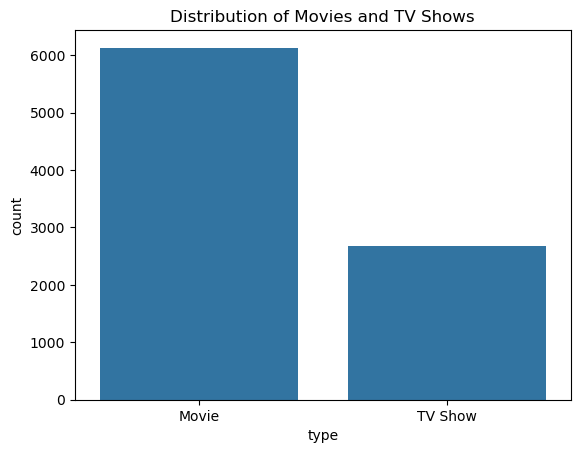

In [28]:
sns.countplot(x="type", data=df)
plt.title("Distribution of Movies and TV Shows")
plt.savefig("content_type_distribution.png") 

## Content Type Analysis

The dataset shows a clear imbalance between the two types of content available on the platform, with movies significantly outnumbering television productions.

### Findings

* Movies make up approximately 70% of the total catalog.
* TV Shows account for the remaining 30% of the dataset.

### Insights

* Netflix's historical library relies heavily on single-sitting feature films.
* TV Shows represent a smaller but growing segment of the platform.

### Business Impact

* Licensing budgets should balance the high volume of movies with high-engagement TV series.
* Recommendation engines must balance movie suggestions with episodic content to maximize watch time.

# **---------------------------------------------------------------------------------------**

## **Movie Duration Distribution**

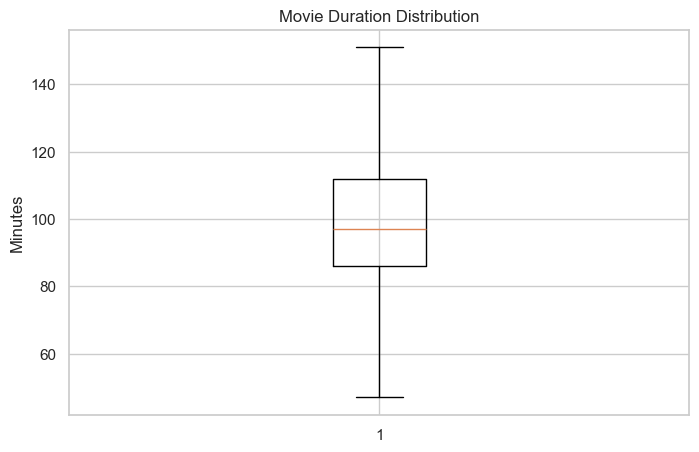

In [63]:
plt.figure(figsize=(8, 5))
plt.boxplot(movies['duration_num'], showfliers=False)
plt.title("Movie Duration Distribution")
plt.ylabel("Minutes")
plt.show()

#### Movie Duration Distribution

Netflix's movie catalog includes films with a wide range of durations, with most movies falling within a standard runtime range. This reflects the platform's focus on offering content that aligns with typical viewer preferences and viewing habits.

#### Findings

* Most movies have a duration between 80 and 120 minutes.
* Very short and very long movies are less common.
* The distribution is concentrated around standard feature-film lengths.
* A few movies have unusually long runtimes.

#### Insights

* Netflix primarily offers movies with conventional runtimes.
* Standard-length movies are likely preferred by a large audience.
* Extreme-duration movies serve niche viewer interests.

#### Business Impact

* Understanding duration trends helps optimize content production and acquisition.
* Standard-length movies may improve viewer completion rates.
* Runtime analysis can support content scheduling and recommendation strategies.

# **-------------------------------------------------------------------------------------**

## **TV Show Seasons Distribution**

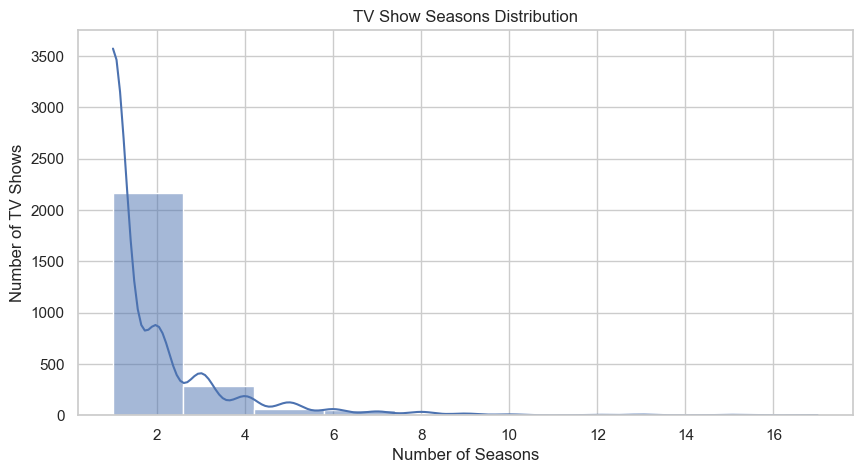

In [66]:
tv = df[df['type'] == 'TV Show'].copy()
tv['season_num'] = tv['duration'].str.extract(r'(\d+)').astype(int)
plt.figure(figsize=(10, 5))
sns.histplot(data=tv, x='season_num', bins=10, kde=True)
plt.title("TV Show Seasons Distribution")
plt.xlabel("Number of Seasons")
plt.ylabel("Number of TV Shows")
plt.show()

#### TV Show Seasons Distribution

The catalog’s TV show distribution displays a highly steep, right-skewed layout where the vast majority of series consist of only a single season. As the number of seasons increases, the volume of available titles drops off dramatically, reflecting the standard lifecycle constraints of streaming episodic content.

#### Findings

* Heavy Single-Season Concentration: The overwhelming majority of TV shows on the platform do not progress past Season 1.
* Rapid Retention Drop-off: There is a steep decline in title counts moving from Season 1 to Season 2, and further drops beyond Season 3.
* Outlier Longevity: Only a microscopic fraction of elite, highly successful series manage to sustain a lifecycle lasting 5 to 10+ seasons.

#### Insights

* The Renewal Challenge: Producing subsequent seasons represents a significant financial risk; the data shows the platform aggressively filters and cancels underperforming shows early.
* Viewer Fatigue or Completion Dynamics: Audiences are more likely to commit to short-form or single-season series, leading the platform to favor volume in new intellectual properties over continuing older ones.
* Clustering of Modern Formats: A substantial portion of the catalog relies on limited docuseries, reality TV, or anime structures designed from day one to be single-season packages.

#### Business Impact

* Content Acquisition Strategy: Instead of funding long-running, multi-season legacy programs that require massive licensing or production costs, the business can maximize subscriber acquisition by continuously launching fresh "Season 1" titles to capture trending cultural conversations.
* Churn Prevention vs. Cost Control: While long-running shows build dedicated fandoms that keep users subscribed, the sharp drop-off suggests the platform acts decisively on a cost-per-view basis—cutting shows whose viewership no longer justifies production increases.
* User Recommendation Tuning: The platform's algorithm should heavily promote new releases or highly bite-sized 1-season completions to casual users, while strategically reserving long-running franchises to re-engage hardcore fans at risk of churning.

# **----------------------------------------------------------------------------------------**

## **Release Year Distribution**

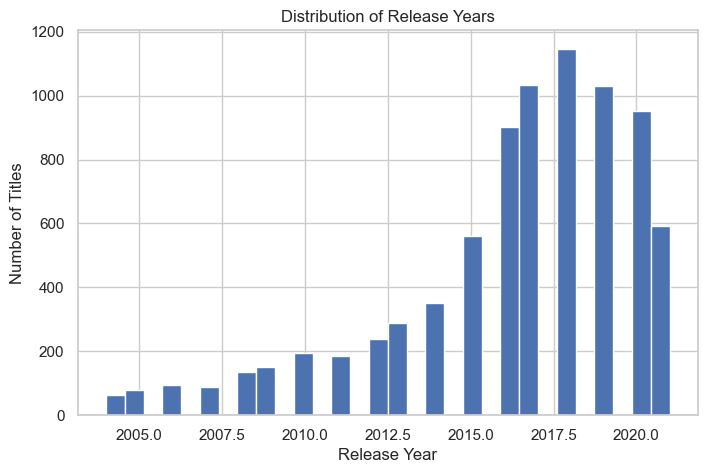

In [68]:
plt.figure(figsize=(8,5))
df['release_year'].hist(bins=30)

plt.title("Distribution of Release Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()

#### Release Year Distribution

Netflix's catalog includes content released across many years, with most titles concentrated in recent decades. This reflects the platform's strong focus on offering modern and recently produced content to its global audience.

#### Findings

* Most titles were released after 2000.
* Content production increased significantly in recent years.
* Older titles represent a smaller portion of the catalog. 
* The highest concentration of titles is found in the last two decades.

#### Insights

* Netflix focuses heavily on recent and modern content.
* Newer releases dominate the platform's library.
* Older titles are included to provide variety and historical content.

#### Business Impact

* Investing in newer content can improve viewer engagement.
* Understanding release trends helps guide content acquisition strategies.
* Maintaining a balance between classic and modern titles can attract a wider audience.

# **------------------------------------------------------------------------------------------**

## **Top Genres**

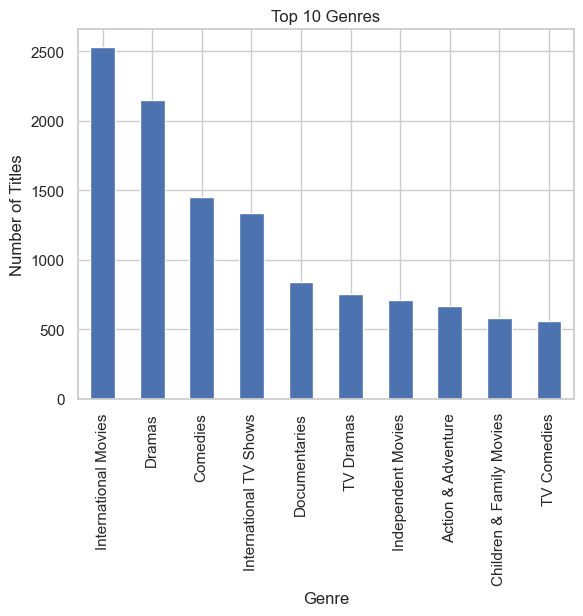

In [71]:
df['listed_in'].str.split(', ').explode().value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")
plt.savefig(r"top_genres.png")
plt.show()


## Top Genres

Netflix offers content across a wide range of genres, with a few categories dominating the catalog.

#### Findings

* Drama is among the most common genres.
* International Movies have strong representation.
* Comedy and Documentaries are also popular categories.

#### Insights

* Diverse genre offerings appeal to a broad audience.
* International content is a major part of Netflix's strategy.
* Popular genres contribute significantly to viewer engagement.

#### Business Impact

* Genre-based recommendations can improve user satisfaction.
* Investment in high-demand genres may increase viewership.
* Genre analysis supports content acquisition planning.

# **------------------------------------------------------------------------------------------**

## **BIVARIATE ANALYSIS**

## **Release Year VS Movie Duration**

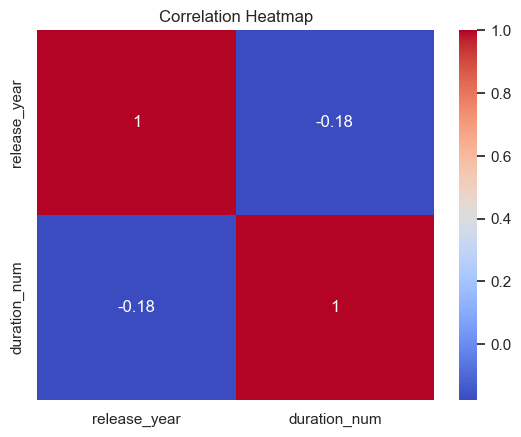

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

df['release_year'] = pd.to_numeric(df['release_year'])

movies = df[df['type'] == 'Movie'].copy()
movies['duration_num'] = movies['duration'].str.extract('(\d+)').astype(float)

corr = movies[['release_year', 'duration_num']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### Release Year VS Movie Duration

This heatmap shows the correlation between a movie's release year and its duration. It helps identify whether movie lengths have changed over time.

#### Findings

* The correlation between release year and movie duration is weak.
* Movie duration does not significantly depend on the release year.
* Both older and newer movies have a wide range of durations.

#### Insights

* Netflix maintains a variety of movie lengths across different years.
* Viewer preferences for movie duration appear to remain diverse over time.
* Release year alone is not a strong predictor of movie length.

#### Business Impact

* Netflix should continue offering movies of different durations to satisfy diverse audience preferences.
* Content acquisition decisions should not rely solely on release year when considering movie length.
* Recommendation systems can focus on user viewing behavior rather than release year for duration-based suggestions.

# **--------------------------------------------------------------------------------------**

## **Top 10 Content-Producing Countries**

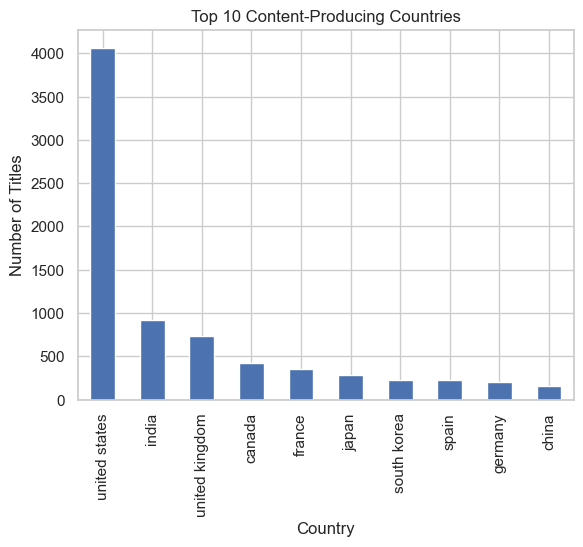

In [78]:
top_countries = (
    df['country']
    .str.split(', ')
    .explode()
    .value_counts()
    .head(10)
)

top_countries.plot(kind='bar')

plt.title("Top 10 Content-Producing Countries")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.show()

### Top 10 Content-Producing Countries

Netflix content is produced across many countries, with a few nations contributing a large share of the catalog. This highlights Netflix's strong presence in major entertainment markets and its growing global reach.


#### Findings

United States contributes the most content. India and the United Kingdom are major contributors.

#### Insights

Netflix relies on content from a few key regions. International content plays an important role.

#### Business Impact

Expanding content production in emerging markets may increase growth. Regional strategies can improve audience engagement.

# **------------------------------------------------------------------------------------------**

## **Release Year vs Type**

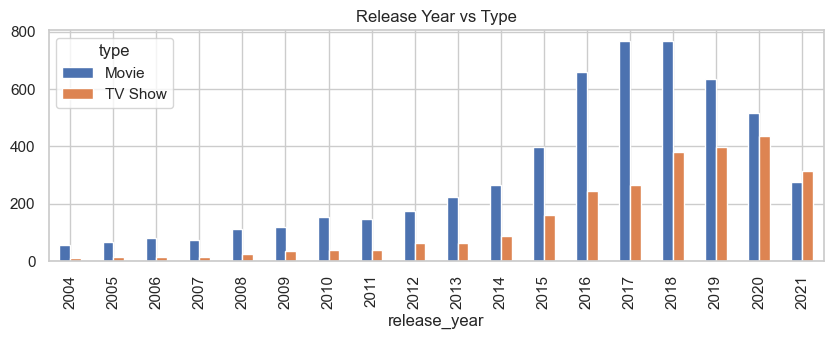

In [102]:
year_type = pd.crosstab(df['release_year'], df['type'])

year_type.tail(20).plot(kind='bar', figsize=(10,3))

plt.title("Release Year vs Type")
plt.show()

### Release Year vs Type

Both Movies and TV Shows have increased over recent years, reflecting Netflix's growing content library.

#### Findings

* The number of Movies and TV Shows has increased significantly in recent years.
* Movies consistently outnumber TV Shows across most release years.
* TV Show releases have grown rapidly in the last decade.
* Older content represents a smaller portion of the catalog.

#### Insights

* Netflix focuses heavily on adding recent content to attract viewers.
* The platform continues to expand its TV Show offerings alongside Movies.
* Viewer demand for original and serialized content may be driving TV Show growth.

#### Business Impact

* Supports decisions on future content production and acquisition.
* Helps Netflix maintain a balanced content portfolio between Movies and TV Shows.
* Understanding release trends can improve content planning and audience engagement strategies.

# **------------------------------------------------------------------------------------------**

## Overall Business Insights

he Netflix content analysis shows that Movies dominate the platform's catalog, although TV Shows have grown significantly in recent years. Content production has increased steadily over time, with most titles released after 2010, reflecting Netflix's focus on modern and trending entertainment.

The analysis also reveals that a small number of genres, countries, and content ratings contribute a large share of the catalog. The United States leads content production, while ratings such as TV-MA and TV-14 are the most common, indicating a strong focus on teen and adult audiences.

## Final Recommendations

* Continue investing in high-demand genres such as Dramas, International TV Shows, and Comedies.
* Expand content production in emerging international markets to attract global audiences.
* Maintain a balanced mix of Movies and TV Shows to serve different viewer preferences.
* Increase family-friendly and children's content to broaden audience reach.
* Use content rating trends to improve recommendation systems and audience targeting.
* Analyze underrepresented genres for potential growth opportunities.

## Conclusion

Netflix's catalog is dominated by Movies, with significant growth in TV Shows over recent years. The platform focuses primarily on Drama, International, and Comedy content, while the United States remains the leading content-producing country. Most titles target teen and adult audiences through TV-MA and TV-14 ratings. These insights can help optimize content strategy, audience engagement, and global expansion efforts.

# **-----------------------------------------------------------------------------------------**